In [1]:
import pandas as pd
import yfinance as yf
import datetime
from datetime import date, timedelta

#calculate date range
today = date.today()
d1 = today.strftime("%Y-%m-%d")
end_date = d1
d2= date.today() - timedelta(days=365)
d2 = d2.strftime("%Y-%m-%d")
start_date = d2

#data load
data = yf.download('AAPL', start=start_date, end=end_date, progress=False)
data['Date'] = data.index
data = data[["Date", "Open", "High", "Low", "Close", "Adj Close", "Volume"]]
data.reset_index(drop=True, inplace=True)
data.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
246,2023-09-07,175.179993,178.210007,173.539993,177.559998,177.559998,112488800
247,2023-09-08,178.350006,180.240005,177.789993,178.179993,178.179993,65551300
248,2023-09-11,180.070007,180.300003,177.339996,179.360001,179.360001,58953100
249,2023-09-12,179.490005,180.130005,174.820007,176.300003,176.300003,90370200
250,2023-09-13,176.509995,177.300003,173.979996,174.210007,174.210007,84267900


In [2]:
print("trainging days =",data.shape)

trainging days = (251, 7)


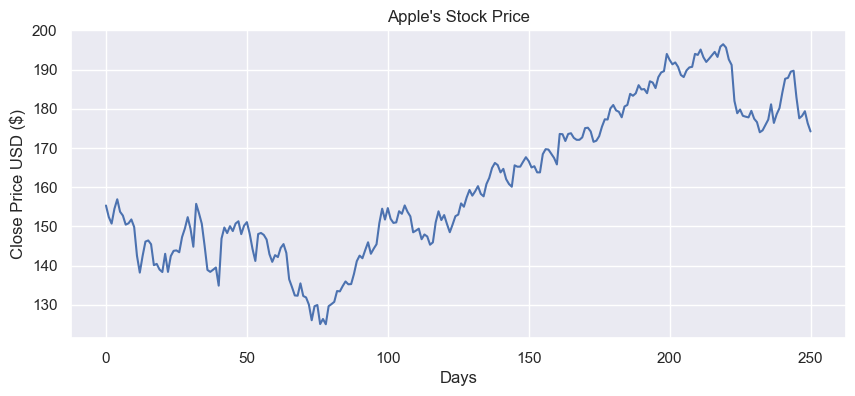

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
plt.figure(figsize=(10, 4))
plt.title("Apple's Stock Price")
plt.xlabel("Days")
plt.ylabel("Close Price USD ($)")
plt.plot(data["Close"])
plt.show()

In [4]:
apple = data
apple = apple[["Close"]]
apple.tail()

,Close
246,177.559998
247,178.179993
248,179.360001
249,176.300003
250,174.210007


Creating a variable to predict ‘X’ days in the future:

In [5]:
futureDays = 25
apple["Prediction"] = apple[["Close"]].shift(-futureDays)
print(apple.head())
print(apple.tail())

        Close  Prediction
0  155.309998  143.860001
1  152.369995  143.389999
2  150.699997  147.270004
3  154.479996  149.449997
4  156.899994  152.339996
          Close  Prediction
246  177.559998         NaN
247  178.179993         NaN
248  179.360001         NaN
249  176.300003         NaN
250  174.210007         NaN


/var/folders/cq/7_5990l175q3y4_djyh7dmsr0000gn/T/ipykernel_70020/3822129132.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  apple["Prediction"] = apple[["Close"]].shift(-futureDays)


To create a feature dataset (x) and convert into a numpy array and remove last ‘x’ rows/days:

In [6]:
import numpy as np
x = np.array(apple.drop(["Prediction"], axis=1))[:-futureDays]
print(x)

[[155.30999756]
 [152.36999512]
 [150.69999695]
 [154.47999573]
 [156.8999939 ]
 [153.72000122]
 [152.74000549]
 [150.42999268]
 [150.77000427]
 [151.75999451]
 [149.83999634]
 [142.47999573]
 [138.19999695]
 [142.44999695]
 [146.1000061 ]
 [146.3999939 ]
 [145.42999268]
 [140.08999634]
 [140.41999817]
 [138.97999573]
 [138.33999634]
 [142.99000549]
 [138.38000488]
 [142.41000366]
 [143.75      ]
 [143.86000061]
 [143.38999939]
 [147.27000427]
 [149.44999695]
 [152.33999634]
 [149.3500061 ]
 [144.80000305]
 [155.74000549]
 [153.33999634]
 [150.6499939 ]
 [145.02999878]
 [138.88000488]
 [138.38000488]
 [138.91999817]
 [139.5       ]
 [134.86999512]
 [146.86999512]
 [149.69999695]
 [148.27999878]
 [150.03999329]
 [148.78999329]
 [150.72000122]
 [151.28999329]
 [148.00999451]
 [150.17999268]
 [151.07000732]
 [148.11000061]
 [144.22000122]
 [141.16999817]
 [148.02999878]
 [148.30999756]
 [147.80999756]
 [146.63000488]
 [142.91000366]
 [140.94000244]
 [142.6499939 ]
 [142.16000366]
 [144.49

In [7]:
y = np.array(apple["Prediction"])[:-futureDays]
print(y)

[143.86000061 143.38999939 147.27000427 149.44999695 152.33999634
 149.3500061  144.80000305 155.74000549 153.33999634 150.6499939
 145.02999878 138.88000488 138.38000488 138.91999817 139.5
 134.86999512 146.86999512 149.69999695 148.27999878 150.03999329
 148.78999329 150.72000122 151.28999329 148.00999451 150.17999268
 151.07000732 148.11000061 144.22000122 141.16999817 148.02999878
 148.30999756 147.80999756 146.63000488 142.91000366 140.94000244
 142.6499939  142.16000366 144.49000549 145.47000122 143.21000671
 136.5        134.50999451 132.36999512 132.30000305 135.44999695
 132.22999573 131.86000061 130.02999878 126.04000092 129.61000061
 129.92999268 125.06999969 126.36000061 125.01999664 129.61999512
 130.1499939  130.72999573 133.49000549 133.41000366 134.75999451
 135.94000244 135.21000671 135.27000427 137.86999512 141.11000061
 142.52999878 141.86000061 143.96000671 145.92999268 143.
 144.28999329 145.42999268 150.82000732 154.5        151.72999573
 154.6499939  151.91999817

In [8]:
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2)

In [9]:
# Creating the decision tree regressor model
from sklearn.tree import DecisionTreeRegressor
tree = DecisionTreeRegressor().fit(xtrain, ytrain)

# creating the Linear Regression model
from sklearn.linear_model import LinearRegression
linear = LinearRegression().fit(xtrain, ytrain)

In [10]:
xfuture = apple.drop(["Prediction"], axis=1)[:-futureDays]
xfuture = xfuture.tail(futureDays)
xfuture = np.array(xfuture)
print(xfuture)

[[191.33000183]
 [191.80999756]
 [190.67999268]
 [188.61000061]
 [188.08000183]
 [189.77000427]
 [190.53999329]
 [190.69000244]
 [193.99000549]
 [193.72999573]
 [195.1000061 ]
 [193.13000488]
 [191.94000244]
 [192.75      ]
 [193.61999512]
 [194.5       ]
 [193.22000122]
 [195.83000183]
 [196.44999695]
 [195.61000061]
 [192.58000183]
 [191.16999817]
 [181.99000549]
 [178.8500061 ]
 [179.80000305]]


In [11]:
treePrediction = tree.predict(xfuture)
print("Decision Tree prediction =",treePrediction)

Decision Tree prediction = [178.19000244 177.97000122 177.78999329 179.46000671 177.44999695
 181.99000549 174.         174.49000549 175.83999634 177.22999573
 181.11999512 176.38000488 177.97000122 180.19000244 184.11999512
 175.83999634 187.86999512 189.69999695 189.69999695 181.11999512
 177.55999756 178.19000244 179.36000061 190.53999329 174.21000671]


In [12]:
linearPrediction = linear.predict(xfuture)
print("Linear regression Prediction =",linearPrediction)

Linear regression Prediction = [189.5987425  189.99531433 189.06170581 187.35148115 186.91359687
 188.30987462 188.9460385  189.06997587 191.79643395 191.58161423
 192.71351497 191.0859026  190.10272419 190.77194308 191.49073188
 192.21779073 191.16025746 193.31663646 193.82887559 193.13487174
 190.63149082 189.46654769 181.88205008 179.2877868  180.072673  ]


/var/folders/cq/7_5990l175q3y4_djyh7dmsr0000gn/T/ipykernel_70020/2779394554.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid["Predictions"] = predictions


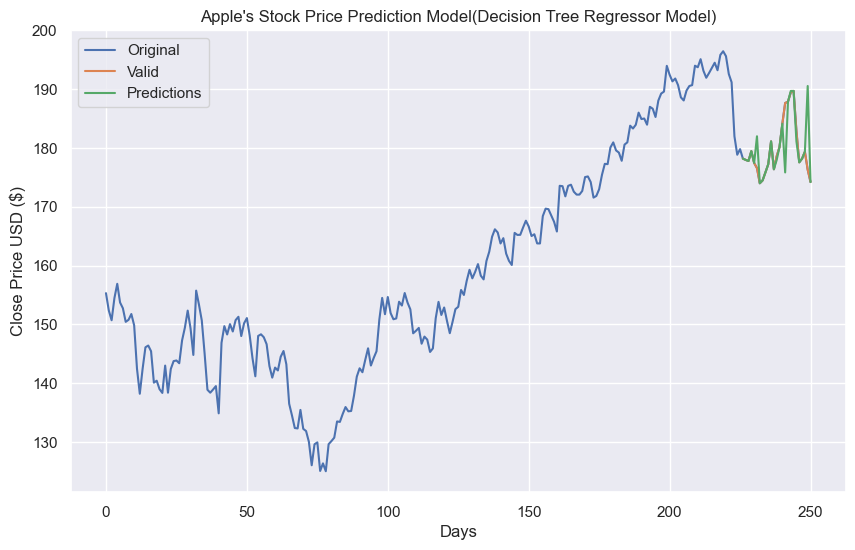

In [13]:
predictions = treePrediction
valid = apple[x.shape[0]:]
valid["Predictions"] = predictions
plt.figure(figsize=(10, 6))
plt.title("Apple's Stock Price Prediction Model(Decision Tree Regressor Model)")
plt.xlabel("Days")
plt.ylabel("Close Price USD ($)")
plt.plot(apple["Close"])
plt.plot(valid[["Close", "Predictions"]])
plt.legend(["Original", "Valid", "Predictions"])
plt.show()

/var/folders/cq/7_5990l175q3y4_djyh7dmsr0000gn/T/ipykernel_70020/93325786.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid["Predictions"] = predictions


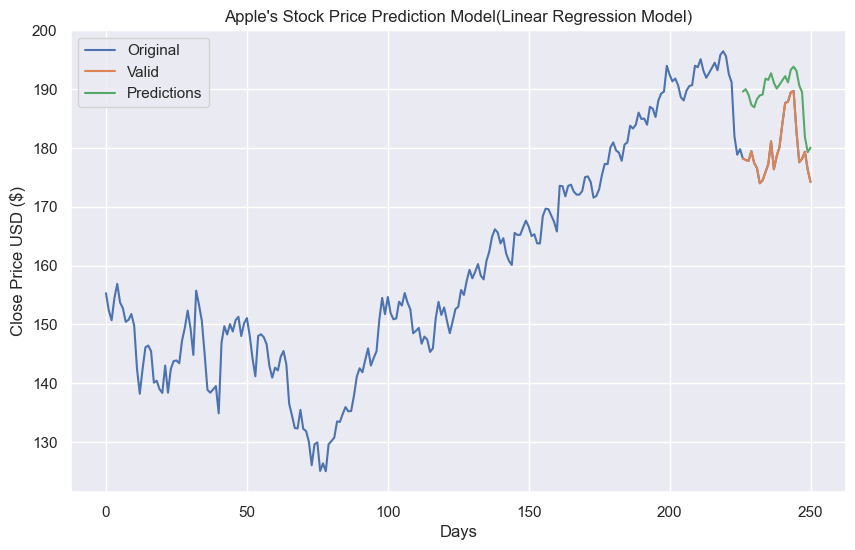

In [14]:
predictions = linearPrediction
valid = apple[x.shape[0]:]
valid["Predictions"] = predictions
plt.figure(figsize=(10, 6))
plt.title("Apple's Stock Price Prediction Model(Linear Regression Model)")
plt.xlabel("Days")
plt.ylabel("Close Price USD ($)")
plt.plot(apple["Close"])
plt.plot(valid[["Close", "Predictions"]])
plt.legend(["Original", "Valid", "Predictions"])
plt.show()

/var/folders/cq/7_5990l175q3y4_djyh7dmsr0000gn/T/ipykernel_70020/70960717.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid["Predictions"] = predictions
/var/folders/cq/7_5990l175q3y4_djyh7dmsr0000gn/T/ipykernel_70020/70960717.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  l_valid["Predictions"] = l_predictions


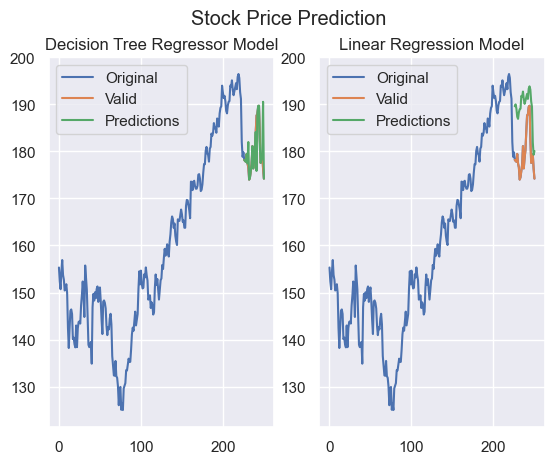

23/09/15 02:19:11 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 1071178 ms exceeds timeout 120000 ms
23/09/15 02:19:11 WARN SparkContext: Killing executors is not supported by current scheduler.


In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2)
fig.suptitle('Stock Price Prediction')
predictions = treePrediction
valid = apple[x.shape[0]:]
valid["Predictions"] = predictions
ax1.set_title('Decision Tree Regressor Model')
#ax1.xlabel("Days")
#ax1.ylabel("Close Price USD ($)")
ax1.plot(apple["Close"])
ax1.plot(valid[["Close", "Predictions"]])
ax1.legend(["Original", "Valid", "Predictions"])
##2nd graph
l_predictions = linearPrediction
l_valid = apple[x.shape[0]:]
l_valid["Predictions"] = l_predictions
#ax2.figure(figsize=(10, 6))
ax2.set_title("Linear Regression Model")
#ax2.xlabel("Days")
#ax2.ylabel("Close Price USD ($)")
ax2.plot(apple["Close"])
ax2.plot(l_valid[["Close", "Predictions"]])
ax2.legend(["Original", "Valid", "Predictions"])
plt.show()